# Latent Flow Matching for the MNIST dataset

The purpose of this notebook is to test the Latent Flow Matching architecture for the MNIST dataset. This can later serve as the baseline to be adapted for the use case at hand. In particular the variant implemented here is Optimal Transport Conditional Flow Matching (OT-CFM) on a latent space produced by a Variational Autoencoder (VAE). The task is to generate different looking variants of a provided image of a digit (the condition), so the training data points for OT-CFM are pairs (condition and target) of MNIST digits which both belong to the same class.

## Imports and  setup

In [1]:
import copy
import time

import matplotlib.pyplot as plt
import numpy as np
import optuna
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import datasets, transforms

In [2]:
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"CUDA version: {torch.version.cuda}")

PyTorch version: 2.11.0+cu128
CUDA available: True
CUDA version: 12.8


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [4]:
# Context manager for timing execution
class Timer:
    def __init__(self, task_name):
        self.task_name = task_name

    def __enter__(self):
        self.start = time.perf_counter()
        return self

    def __exit__(self, *args):
        self.end = time.perf_counter()
        seconds = int(self.end - self.start)

        hours = seconds // 3600
        minutes = (seconds % 3600) // 60
        secs = seconds % 60

        print(f"{self.task_name} time: {hours:02}:{minutes:02}:{secs:02}")

In [5]:
# Data config
DATA_SHAPE = (1, 28, 28)
LATENT_DIM = 32
OUTPUT_PADDING = (1, 1)
TRAIN_SIZE = 50000
VAL_SIZE = 10000

# VAE config
BATCH_SIZE_VAE = 1024
EPOCHS_VAE = 1000
OPTUNA_TRIALS_VAE = 30
PATIENCE_VAE = 25

# OT-CFM config
BATCH_SIZE_FM = 1024
EPOCHS_FM = 1000
OPTUNA_TRIALS_FM = 15
PATIENCE_FM = 25
STEPS_LIST = [10, 20, 30, 40, 50]

## MNIST loading

In [6]:
# Load the full training set
full_train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transforms.ToTensor())

# Split the dataset
train_dataset, val_dataset = random_split(full_train_dataset, [TRAIN_SIZE, VAL_SIZE])

# Create the data loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE_VAE, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE_VAE, shuffle=False)

# Keep the test set totally separate for the very end
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transforms.ToTensor())
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE_VAE, shuffle=False)

## VAE model

In [7]:
# We use convolutions here since the input is an image
class ConvVAE(nn.Module):
    def __init__(
        self,
        convolution_channel_count,
        beta,
        dropout_rate,
        input_shape=DATA_SHAPE,
        latent_dim=LATENT_DIM,
        output_padding=OUTPUT_PADDING,
    ):
        super().__init__()

        # General settings for the architecture
        kernel_size = 3
        stride = 2
        padding = 1

        # Define attributes
        self.input_shape = input_shape
        self.beta = beta

        # There is double the channels in the second convolution
        second_convolution_channel_count = convolution_channel_count * 2

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(
                self.input_shape[0], convolution_channel_count, kernel_size=kernel_size, stride=stride, padding=padding
            ),
            nn.SiLU(),
            nn.Dropout2d(dropout_rate),
            nn.Conv2d(
                convolution_channel_count,
                second_convolution_channel_count,
                kernel_size=kernel_size,
                stride=stride,
                padding=padding,
            ),
            nn.SiLU(),
            nn.Dropout2d(dropout_rate),
            nn.Flatten(),
        )

        # Calculate the size of the resulting image after flattening
        output_image_height = ((self.input_shape[1] - kernel_size + 2 * padding) // stride) + 1
        output_image_height = ((output_image_height - kernel_size + 2 * padding) // stride) + 1
        output_image_width = ((self.input_shape[2] - kernel_size + 2 * padding) // stride) + 1
        output_image_width = ((output_image_width - kernel_size + 2 * padding) // stride) + 1
        flattened_size = second_convolution_channel_count * output_image_height * output_image_width

        # Latent space bottlenecks
        self.fc_mu = nn.Linear(flattened_size, latent_dim)
        self.fc_logvar = nn.Linear(flattened_size, latent_dim)

        # Decoder input
        self.decoder_input = nn.Linear(
            latent_dim, second_convolution_channel_count * output_image_height * output_image_width
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Unflatten(1, (second_convolution_channel_count, output_image_height, output_image_width)),
            nn.ConvTranspose2d(
                second_convolution_channel_count,
                convolution_channel_count,
                kernel_size=kernel_size,
                stride=stride,
                padding=padding,
                output_padding=output_padding[0],
            ),
            nn.SiLU(),
            nn.Dropout2d(dropout_rate),
            nn.ConvTranspose2d(
                convolution_channel_count,
                self.input_shape[0],
                kernel_size=kernel_size,
                stride=stride,
                padding=padding,
                output_padding=output_padding[1],
            ),
        )

    def encode(self, x):
        result = self.encoder(x)
        return self.fc_mu(result), self.fc_logvar(result)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        result = self.decoder_input(z)
        result = self.decoder(result)
        return result

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

    def loss_function(self, x, recon_x, mu, logvar):
        # This scaling factor is used to prevent the loss being too small and to make it independent of data size
        scaling_factor = 1e2 / (self.input_shape[0] * self.input_shape[1] * self.input_shape[2] * x.size(0))

        # Calculate the components of the loss
        BCE = nn.functional.binary_cross_entropy_with_logits(recon_x, x, reduction="sum")
        KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

        # Calculate and scale the loss
        scaled_BCE = BCE * scaling_factor
        scaled_KLD = KLD * scaling_factor
        scaled_loss = scaled_BCE + self.beta * scaled_KLD

        return scaled_loss, scaled_BCE, scaled_KLD

    def calculate_batch_loss(self, x):
        return self.loss_function(x, *self(x))

In [8]:
# Function for training VAE
def train_vae(model, optimizer, train_loader, val_loader, epochs=EPOCHS_VAE, patience=PATIENCE_VAE, plot_curves=False):
    best_val_loss = float("inf")
    epochs_no_improve = 0
    best_model_wts = copy.deepcopy(model.state_dict())

    # Lists to store loss history for plotting
    history = {
        "train": [],
        "val": [],
    }

    for epoch in range(epochs):
        # TRAINING PHASE
        model.train()
        train_loss = 0
        for data, _ in train_loader:
            data = data.to(device)
            optimizer.zero_grad()
            loss, _, _ = model.calculate_batch_loss(data)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)
        history["train"].append(avg_train_loss)

        # VALIDATION PHASE
        model.eval()
        val_loss = 0
        val_BCE = 0
        val_KLD = 0
        with torch.no_grad():
            for data, _ in val_loader:
                data = data.to(device)
                v_loss, v_BCE, v_KLD = model.calculate_batch_loss(data)
                val_loss += v_loss.item()
                val_BCE += v_BCE.item()
                val_KLD += v_KLD.item()

        avg_val_loss = val_loss / len(val_loader)
        avg_val_BCE = val_BCE / len(val_loader)
        avg_val_KLD = val_KLD / len(val_loader)
        history["val"].append(avg_val_loss)

        # LOGGING
        if epoch % 25 == 0:
            print(
                f"Epoch {epoch + 1:02d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val BCE: {avg_val_BCE:.4f} | Val KLD: {avg_val_KLD:.4f}"
            )

        # EARLY STOPPING LOGIC
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_no_improve = 0
            # Save the best version of the model
            best_model_wts = copy.deepcopy(model.state_dict())
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping triggered at epoch {epoch + 1}. Restoring best weights")
                break

    # Always return the best model
    model.load_state_dict(best_model_wts)

    # Plot the loss curves (can be turned on and off)
    if plot_curves:
        plt.figure(figsize=(10, 5))
        plt.plot(history["train"], label="Training Loss")
        plt.plot(history["val"], label="Validation Loss")
        plt.xlabel("Epochs")
        plt.ylabel("Loss")
        plt.title("VAE Training and Validation Loss")
        plt.legend()
        plt.grid(True)
        plt.show()

    return model, best_val_loss

In [9]:
def objective(trial):
    # Suggest model hyperparameters
    convolution_channel_count = trial.suggest_categorical("convolution_channel_count", [16, 32, 64])
    beta = trial.suggest_float("beta", 0.001, 1, log=True)
    dropout_rate = trial.suggest_float("dropout_rate", 0.0, 0.5)

    # Suggest training hyperparameters
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)

    # Setup Model & Optimizer
    model = ConvVAE(
        convolution_channel_count=convolution_channel_count,
        beta=beta,
        dropout_rate=dropout_rate,
    ).to(device)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay,
    )

    # Do full training
    with Timer("VAE Training"):
        model, _ = train_vae(model, optimizer, train_loader, val_loader)

    # Standardize the loss used for comparing results
    model.eval()
    standardized_val_loss = 0
    with torch.no_grad():
        for data, _ in val_loader:
            data = data.to(device)
            recon, mu, logvar = model(data)

            # Use BCE and a fixed beta of 0.1 for scoring
            standardized_val_loss += nn.functional.binary_cross_entropy_with_logits(
                recon, data, reduction="sum"
            ).item() - 0.05 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    return standardized_val_loss


# Create a study that minimizes our validation loss
study = optuna.create_study(study_name="Tuning - VAE")
with Timer("VAE Tuning"):
    study.optimize(objective, n_trials=OPTUNA_TRIALS_VAE)

# Save the results
trial_vae = study.best_trial

print("Best trial:")
print(f"Value: {trial_vae.value}")
print(f"Params: {trial_vae.params}")

[I 2026-04-18 01:51:29,131] A new study created in memory with name: Tuning - VAE


Epoch 01 | Train Loss: 47.7736 | Val Loss: 27.0669 | Val BCE: 26.9860 | Val KLD: 36.6597
Epoch 26 | Train Loss: 8.9632 | Val Loss: 8.5482 | Val BCE: 8.4813 | Val KLD: 30.3653
Epoch 51 | Train Loss: 8.3164 | Val Loss: 7.9873 | Val BCE: 7.9259 | Val KLD: 27.8415
Epoch 76 | Train Loss: 8.0403 | Val Loss: 7.7436 | Val BCE: 7.6843 | Val KLD: 26.8680
Epoch 101 | Train Loss: 7.8837 | Val Loss: 7.6027 | Val BCE: 7.5447 | Val KLD: 26.3083
Epoch 126 | Train Loss: 7.7827 | Val Loss: 7.5144 | Val BCE: 7.4579 | Val KLD: 25.6200
Epoch 151 | Train Loss: 7.7172 | Val Loss: 7.4577 | Val BCE: 7.4027 | Val KLD: 24.9676
Epoch 176 | Train Loss: 7.6711 | Val Loss: 7.4144 | Val BCE: 7.3607 | Val KLD: 24.3621
Epoch 201 | Train Loss: 7.6334 | Val Loss: 7.3831 | Val BCE: 7.3308 | Val KLD: 23.7362
Epoch 226 | Train Loss: 7.6039 | Val Loss: 7.3582 | Val BCE: 7.3065 | Val KLD: 23.4246
Epoch 251 | Train Loss: 7.5805 | Val Loss: 7.3369 | Val BCE: 7.2862 | Val KLD: 22.9965
Epoch 276 | Train Loss: 7.5608 | Val Loss: 7

[I 2026-04-18 02:14:45,788] Trial 0 finished with value: 724484.75 and parameters: {'convolution_channel_count': 64, 'beta': 0.0022055693214657036, 'dropout_rate': 0.193648683763033, 'lr': 0.00021158087040345377, 'weight_decay': 6.923436976783036e-05}. Best is trial 0 with value: 724484.75.


Epoch 01 | Train Loss: 36.0192 | Val Loss: 19.0728 | Val BCE: 17.3303 | Val KLD: 4.6185
Epoch 26 | Train Loss: 11.4933 | Val Loss: 10.9029 | Val BCE: 8.6813 | Val KLD: 5.8885
Epoch 51 | Train Loss: 11.2395 | Val Loss: 10.7142 | Val BCE: 8.5218 | Val KLD: 5.8113
Epoch 76 | Train Loss: 11.1696 | Val Loss: 10.7533 | Val BCE: 8.6004 | Val KLD: 5.7064
Epoch 101 | Train Loss: 11.1176 | Val Loss: 10.6354 | Val BCE: 8.5186 | Val KLD: 5.6108
Epoch 126 | Train Loss: 11.0817 | Val Loss: 10.5597 | Val BCE: 8.4337 | Val KLD: 5.6350
Early stopping triggered at epoch 132. Restoring best weights
VAE Training time: 00:04:08


[I 2026-04-18 02:18:54,303] Trial 1 finished with value: 705068.8125 and parameters: {'convolution_channel_count': 64, 'beta': 0.37727967579502536, 'dropout_rate': 0.3349981378298892, 'lr': 0.005477063209294127, 'weight_decay': 1.2701669444795635e-06}. Best is trial 1 with value: 705068.8125.


...

Epoch 01 | Train Loss: 72.3291 | Val Loss: 47.8223 | Val BCE: 43.8793 | Val KLD: 20.0269
Epoch 26 | Train Loss: 12.5938 | Val Loss: 12.2465 | Val BCE: 10.6320 | Val KLD: 8.2000
Epoch 51 | Train Loss: 11.0169 | Val Loss: 10.7926 | Val BCE: 9.1510 | Val KLD: 8.3377
Epoch 76 | Train Loss: 10.6137 | Val Loss: 10.4145 | Val BCE: 8.7831 | Val KLD: 8.2860
Epoch 101 | Train Loss: 10.3504 | Val Loss: 10.1462 | Val BCE: 8.5497 | Val KLD: 8.1090
Epoch 126 | Train Loss: 10.1235 | Val Loss: 9.9259 | Val BCE: 8.3583 | Val KLD: 7.9617
Epoch 151 | Train Loss: 9.9777 | Val Loss: 9.7787 | Val BCE: 8.2267 | Val KLD: 7.8829
Epoch 176 | Train Loss: 9.8827 | Val Loss: 9.6893 | Val BCE: 8.1590 | Val KLD: 7.7726
Epoch 201 | Train Loss: 9.8039 | Val Loss: 9.6154 | Val BCE: 8.0963 | Val KLD: 7.7160
Epoch 226 | Train Loss: 9.7531 | Val Loss: 9.5642 | Val BCE: 8.0506 | Val KLD: 7.6881
Epoch 251 | Train Loss: 9.7098 | Val Loss: 9.5259 | Val BCE: 8.0281 | Val KLD: 7.6076
Epoch 276 | Train Loss: 9.6665 | Val Loss: 9

[I 2026-04-18 09:15:56,483] Trial 28 finished with value: 669778.9375 and parameters: {'convolution_channel_count': 16, 'beta': 0.19688522958842386, 'dropout_rate': 0.037833600294241314, 'lr': 0.0002704037775844219, 'weight_decay': 6.028908672426015e-06}. Best is trial 27 with value: 640061.0.


Epoch 01 | Train Loss: 65.1557 | Val Loss: 47.4201 | Val BCE: 42.2755 | Val KLD: 8.7342
Epoch 26 | Train Loss: 14.1702 | Val Loss: 13.8324 | Val BCE: 10.4663 | Val KLD: 5.7147
Epoch 51 | Train Loss: 13.3078 | Val Loss: 13.0393 | Val BCE: 9.7682 | Val KLD: 5.5536
Epoch 76 | Train Loss: 12.8640 | Val Loss: 12.5962 | Val BCE: 9.4432 | Val KLD: 5.3530
Epoch 101 | Train Loss: 12.5323 | Val Loss: 12.2448 | Val BCE: 9.2184 | Val KLD: 5.1381
Epoch 126 | Train Loss: 12.3088 | Val Loss: 12.0285 | Val BCE: 9.0982 | Val KLD: 4.9749
Epoch 151 | Train Loss: 12.1631 | Val Loss: 11.8897 | Val BCE: 9.0012 | Val KLD: 4.9039
Epoch 176 | Train Loss: 12.0476 | Val Loss: 11.7909 | Val BCE: 8.9588 | Val KLD: 4.8082
Epoch 201 | Train Loss: 11.9623 | Val Loss: 11.7017 | Val BCE: 8.8750 | Val KLD: 4.7991
Epoch 226 | Train Loss: 11.9050 | Val Loss: 11.6433 | Val BCE: 8.8394 | Val KLD: 4.7604
Epoch 251 | Train Loss: 11.8569 | Val Loss: 11.5997 | Val BCE: 8.8056 | Val KLD: 4.7436
Epoch 276 | Train Loss: 11.8197 | 

[I 2026-04-18 09:35:35,819] Trial 29 finished with value: 710101.5 and parameters: {'convolution_channel_count': 32, 'beta': 0.58901720300247, 'dropout_rate': 0.09274293463161294, 'lr': 0.0001858264725408001, 'weight_decay': 0.00010801836582497072}. Best is trial 27 with value: 640061.0.


VAE Tuning time: 07:44:06
Best trial:
Value: 640061.0
Params: {'convolution_channel_count': 64, 'beta': 0.07667134583863931, 'dropout_rate': 0.04743910629664383, 'lr': 0.00026624151272071844, 'weight_decay': 4.480874959936773e-06}


Epoch 01 | Train Loss: 41.4471 | Val Loss: 27.9328 | Val BCE: 26.8824 | Val KLD: 13.6993
Epoch 26 | Train Loss: 9.4530 | Val Loss: 9.3141 | Val BCE: 8.4738 | Val KLD: 10.9590
Epoch 51 | Train Loss: 8.9652 | Val Loss: 8.8512 | Val BCE: 8.0281 | Val KLD: 10.7349
Epoch 76 | Train Loss: 8.6831 | Val Loss: 8.5738 | Val BCE: 7.7767 | Val KLD: 10.3962
Epoch 101 | Train Loss: 8.5131 | Val Loss: 8.4193 | Val BCE: 7.6362 | Val KLD: 10.2132
Epoch 126 | Train Loss: 8.4133 | Val Loss: 8.3250 | Val BCE: 7.5442 | Val KLD: 10.1833
Epoch 151 | Train Loss: 8.3380 | Val Loss: 8.2549 | Val BCE: 7.4683 | Val KLD: 10.2601
Epoch 176 | Train Loss: 8.2788 | Val Loss: 8.2011 | Val BCE: 7.4241 | Val KLD: 10.1335
Epoch 201 | Train Loss: 8.2365 | Val Loss: 8.1637 | Val BCE: 7.3894 | Val KLD: 10.0993
Epoch 226 | Train Loss: 8.2042 | Val Loss: 8.1351 | Val BCE: 7.3614 | Val KLD: 10.0906
Epoch 251 | Train Loss: 8.1731 | Val Loss: 8.1044 | Val BCE: 7.3342 | Val KLD: 10.0465
Epoch 276 | Train Loss: 8.1499 | Val Loss: 8

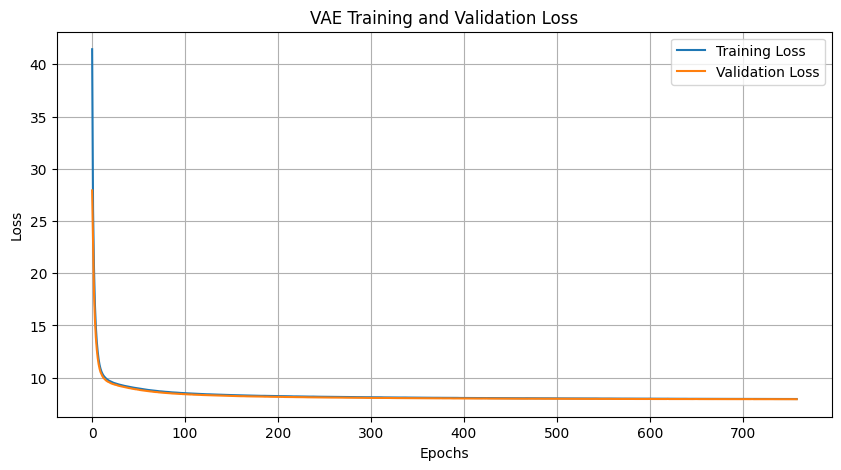

VAE Final Training time: 00:24:24


In [10]:
model_vae = ConvVAE(
    convolution_channel_count=trial_vae.params["convolution_channel_count"],
    beta=trial_vae.params["beta"],
    dropout_rate=trial_vae.params["dropout_rate"],
).to(device)
optimizer_vae = torch.optim.AdamW(
    model_vae.parameters(),
    lr=trial_vae.params["lr"],
    weight_decay=trial_vae.params["weight_decay"],
)

# Retrain the model
with Timer("VAE Final Training"):
    model_vae, _ = train_vae(model_vae, optimizer_vae, train_loader, val_loader, plot_curves=True)

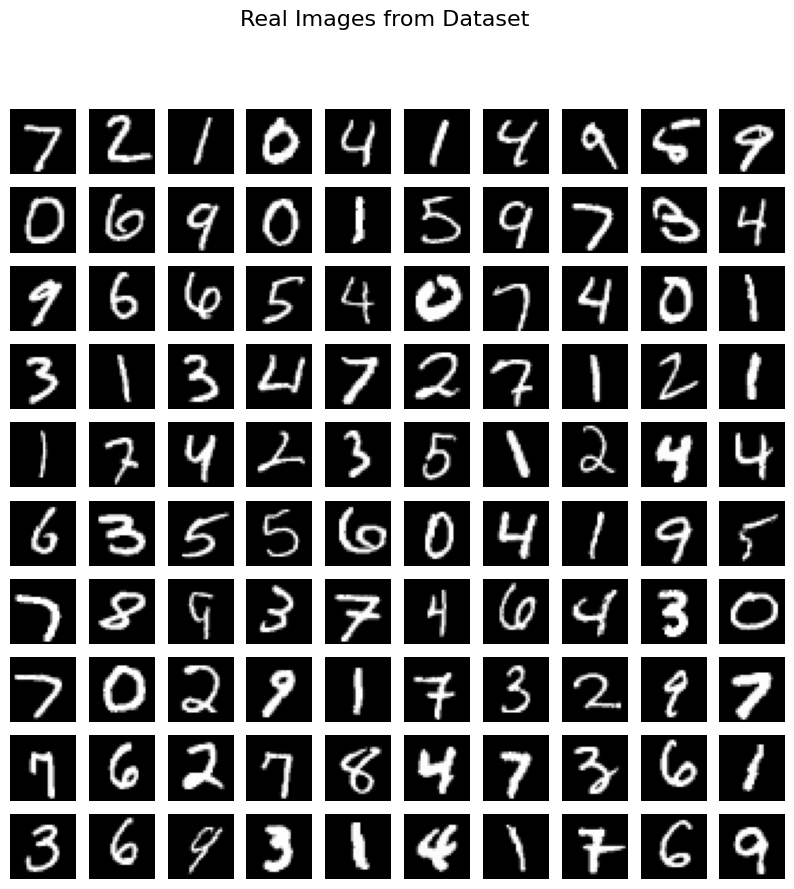

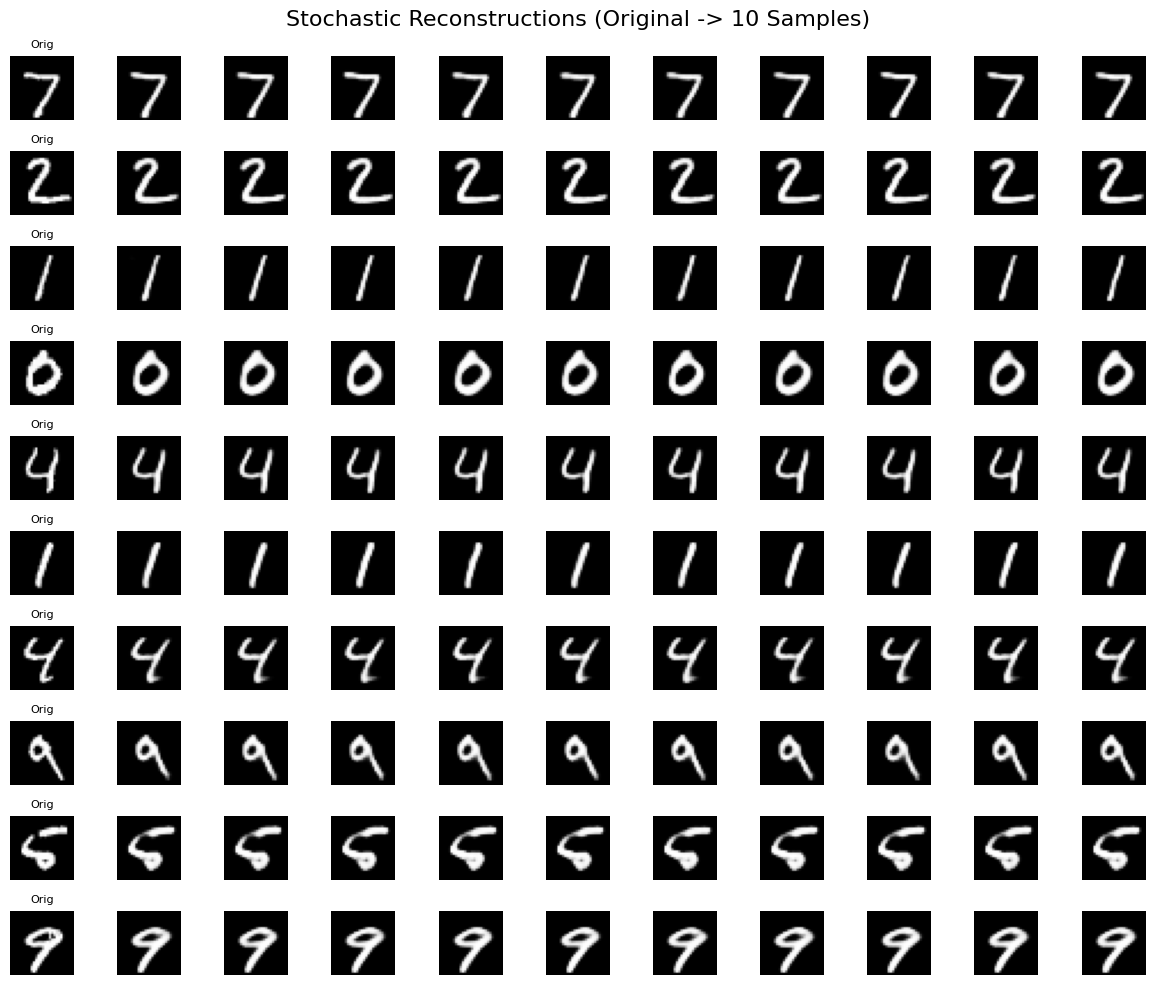

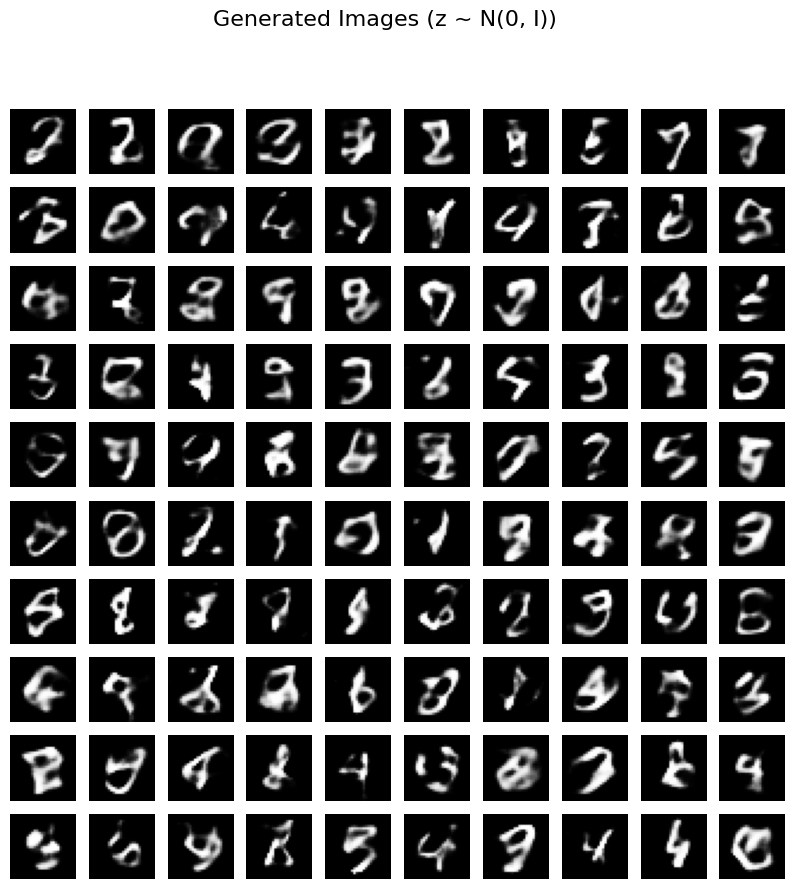

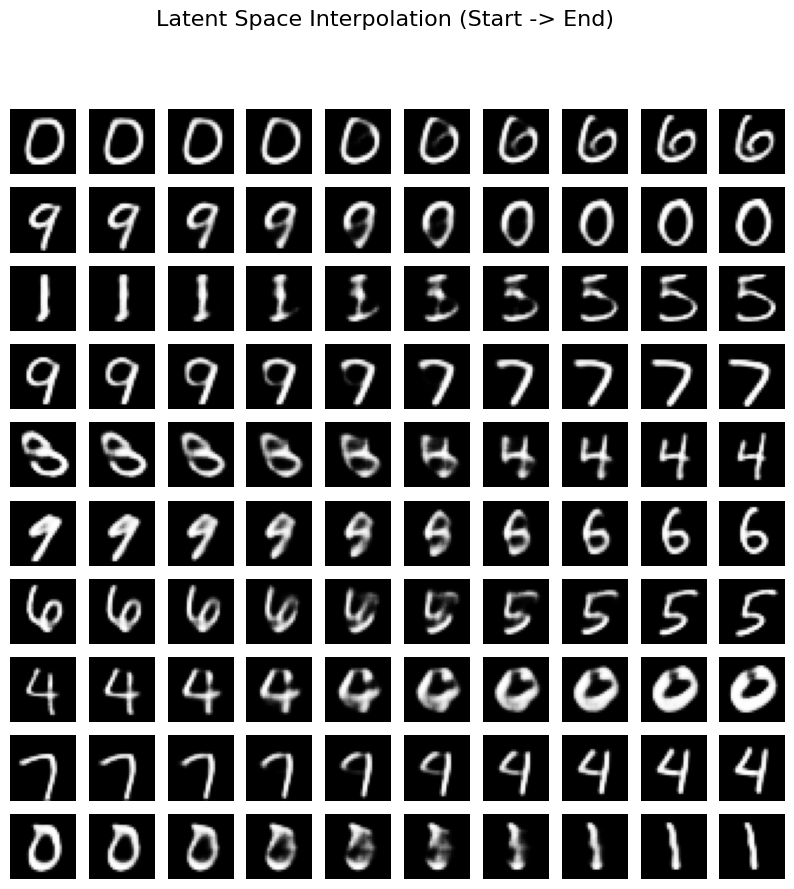

In [11]:
# Function for displaying results
@torch.no_grad()
def visualize_vae_performance(model, data_loader):
    model.eval()

    # Get a batch of real data
    images, _ = next(iter(data_loader))
    images = images.to(device)

    # 100 REAL IMAGES FROM DATASET
    fig1, axes1 = plt.subplots(10, 10, figsize=(10, 10))
    fig1.suptitle("Real Images from Dataset", fontsize=16)
    for i, ax in enumerate(axes1.flat):
        ax.imshow(images[i].cpu().squeeze(), cmap="gray")
        ax.axis("off")
    plt.show()

    # 10 IMAGES: 10 STOCHASTIC RECONSTRUCTIONS EACH
    fig2, axes2 = plt.subplots(10, 11, figsize=(12, 10))
    fig2.suptitle("Stochastic Reconstructions (Original -> 10 Samples)", fontsize=16)

    subset = images[:10]
    mu, logvar = model.encode(subset)

    for i in range(10):
        # Show Original
        axes2[i, 0].imshow(subset[i].cpu().squeeze(), cmap="gray")
        axes2[i, 0].set_title("Orig", fontsize=8)
        axes2[i, 0].axis("off")

        # Show 10 Reconstructions
        for j in range(1, 11):
            z = model.reparameterize(mu[i : i + 1], logvar[i : i + 1])
            recon = torch.sigmoid(model.decode(z))
            axes2[i, j].imshow(recon.cpu().squeeze(), cmap="gray")
            axes2[i, j].axis("off")
    plt.tight_layout()
    plt.show()

    # 100 GENERATED IMAGES (FROM NOISE)
    fig3, axes3 = plt.subplots(10, 10, figsize=(10, 10))
    fig3.suptitle("Generated Images (z ~ N(0, I))", fontsize=16)

    # Sample from standard normal
    z_random = torch.randn(100, model.fc_mu.out_features).to(device)
    generated = torch.sigmoid(model.decode(z_random))

    for i, ax in enumerate(axes3.flat):
        ax.imshow(generated[i].cpu().squeeze(), cmap="gray")
        ax.axis("off")
    plt.show()

    # INTERPOLATION BETWEEN 10 PAIRS
    fig4, axes4 = plt.subplots(10, 10, figsize=(10, 10))
    fig4.suptitle("Latent Space Interpolation (Start -> End)", fontsize=16)

    # Pick 10 pairs (20 images total)
    pair_images = images[10:30]
    mu_pairs, _ = model.encode(pair_images)

    for i in range(10):
        z_start = mu_pairs[i * 2]
        z_end = mu_pairs[i * 2 + 1]

        for j in range(10):
            # Linear interpolation (t from 0 to 1)
            t = j / 9.0
            z_interp = (1 - t) * z_start + t * z_end
            z_interp = z_interp.unsqueeze(0)

            interp_img = torch.sigmoid(model.decode(z_interp))
            axes4[i, j].imshow(interp_img.cpu().squeeze(), cmap="gray")
            axes4[i, j].axis("off")
    plt.show()


visualize_vae_performance(model_vae, test_loader)

## OT-CFM on the latent space

In [12]:
class DiverseMNISTDataset(Dataset):
    def __init__(self, standard_mnist):
        self.standard_mnist = standard_mnist

        # Handle the 'Subset' vs 'Dataset' difference
        if hasattr(standard_mnist, "dataset"):
            # It's a Subset: get targets from the base and slice by indices
            all_targets = standard_mnist.dataset.targets
            self.targets = all_targets[standard_mnist.indices]
        else:
            # It's the raw Dataset
            self.targets = standard_mnist.targets

        # Pre-group indices by digit for O(1) lookup
        self.digit_indices = {i: torch.where(self.targets == i)[0] for i in range(10)}

    def __len__(self):
        return len(self.standard_mnist)

    def __getitem__(self, idx):
        # Get the primary 'Target' image and its label
        target_img, label = self.standard_mnist[idx]
        label_val = label.item() if torch.is_tensor(label) else label

        # Get all indices for this digit class
        indices = self.digit_indices[label_val]
        n_available = len(indices)

        if n_available > 1:
            # Pick a random offset in the range [0, n_available - 2]
            random_offset = torch.randint(0, n_available - 1, (1,)).item()

            # Find where the current 'idx' sits in the filtered list
            target_pos_in_indices = (indices == idx).nonzero(as_tuple=True)[0].item()

            # If the random offset lands on or after the target position,
            # shift it by one to skip the target.
            if random_offset >= target_pos_in_indices:
                random_offset += 1

            random_idx = indices[random_offset].item()
        else:
            # Fallback for classes with only one image (not an issue for MNIST)
            random_idx = idx

        cond_img, _ = self.standard_mnist[random_idx]

        return target_img, cond_img, label

In [13]:
# Wrap existing MNIST datasets
train_diverse = DiverseMNISTDataset(train_dataset)
val_diverse = DiverseMNISTDataset(val_dataset)

# Define DataLoaders for paired data
train_loader_fm = DataLoader(train_diverse, batch_size=BATCH_SIZE_FM, shuffle=True, drop_last=True)
val_loader_fm = DataLoader(val_diverse, batch_size=BATCH_SIZE_FM, shuffle=False)

In [14]:
class VelocityNet(nn.Module):
    def __init__(self, num_layers, hidden_dim, dropout_rate, latent_dim=LATENT_DIM):
        super().__init__()

        # Input = z_t (latent_dim) + time (1) + condition_latent (latent_dim)
        input_dim = latent_dim + 1 + latent_dim

        # The latent size is useful for loss calculation
        self.latent_dim = latent_dim

        layers = []
        current_dim = input_dim

        for _ in range(num_layers):
            layers.append(nn.Linear(current_dim, hidden_dim))
            layers.append(nn.SiLU())
            layers.append(nn.Dropout(dropout_rate))
            current_dim = hidden_dim

        # Final layer maps back to latent_dim (the velocity vector)
        layers.append(nn.Linear(hidden_dim, latent_dim))

        self.net = nn.Sequential(*layers)

    def forward(self, z_t, t, c_latent):
        # t is usually a single float per batch item, needs to be (Batch, 1)
        if t.dim() == 1:
            t = t.unsqueeze(-1)

        # Concatenate everything into one giant conditioning vector
        x = torch.cat([z_t, t, c_latent], dim=-1)
        return self.net(x)

    def calculate_batch_loss(self, z_t, t, c_latent, target_v):
        # This scaling factor is used to prevent the loss being too small and to make it independent of data size
        scaling_factor = 10

        return nn.functional.mse_loss(self(z_t, t, c_latent), target_v) * scaling_factor

In [15]:
# Function for training FM
def train_fm(
    v_net, vae, optimizer, train_loader, val_loader, epochs=EPOCHS_FM, patience=PATIENCE_FM, plot_curves=False
):
    best_val_loss = float("inf")
    epochs_no_improve = 0
    best_model_wts = copy.deepcopy(v_net.state_dict())

    history = {
        "train": [],
        "val": [],
    }

    # Set VAE in evaluation mode
    vae.eval()

    for epoch in range(epochs):
        # TRAINING PHASE
        v_net.train()
        train_loss = 0
        for target_imgs, cond_imgs, _ in train_loader:
            target_imgs, cond_imgs = target_imgs.to(device), cond_imgs.to(device)
            optimizer.zero_grad()

            # Encode images to the latent space
            with torch.no_grad():
                z1, _ = vae.encode(target_imgs)
                c_latent, _ = vae.encode(cond_imgs)

            # Optimal Transport Flow Matching
            z0 = torch.randn_like(z1)
            t = torch.rand(z1.size(0), 1).to(device)
            zt = (1 - t) * z0 + t * z1
            target_v = z1 - z0

            loss = v_net.calculate_batch_loss(zt, t, c_latent, target_v)

            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)
        history["train"].append(avg_train_loss)

        # VALIDATION PHASE
        v_net.eval()
        val_loss = 0
        with torch.no_grad():
            for target_imgs, cond_imgs, _ in val_loader:
                target_imgs, cond_imgs = target_imgs.to(device), cond_imgs.to(device)

                z1, _ = vae.encode(target_imgs)
                c_latent, _ = vae.encode(cond_imgs)

                z0 = torch.randn_like(z1)
                t = torch.rand(z1.size(0), 1).to(device)
                zt = (1 - t) * z0 + t * z1
                target_v = z1 - z0

                v_loss = v_net.calculate_batch_loss(zt, t, c_latent, target_v)
                val_loss += v_loss.item()

        avg_val_loss = val_loss / len(val_loader)
        history["val"].append(avg_val_loss)

        # LOGGING
        if epoch % 25 == 0:
            print(f"Epoch {epoch + 1:02d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

        # EARLY STOPPING
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_no_improve = 0
            best_model_wts = copy.deepcopy(v_net.state_dict())
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping at epoch {epoch + 1}. Restoring best weights")
                break

    v_net.load_state_dict(best_model_wts)

    if plot_curves:
        plt.figure(figsize=(10, 5))
        plt.plot(history["train"], label="Train")
        plt.plot(history["val"], label="Val")
        plt.xlabel("Epochs")
        plt.ylabel("Loss")
        plt.title("VelocityNet CFM Loss")
        plt.legend()
        plt.grid(True)
        plt.show()

    return v_net, best_val_loss

In [16]:
def objective(trial):
    # Suggest model hyperparameters
    num_layers = trial.suggest_int("num_layers", 1, 5)
    hidden_dim = trial.suggest_int("hidden_dim", 128, 1024)
    dropout_rate = trial.suggest_float("dropout_rate", 0.0, 0.5)

    # Suggest training hyperparameters
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)

    # Setup Model & Optimizer
    model = VelocityNet(
        num_layers=num_layers,
        hidden_dim=hidden_dim,
        dropout_rate=dropout_rate,
    ).to(device)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay,
    )

    # Do full training
    with Timer("FM Training"):
        model, best_val_loss = train_fm(model, model_vae, optimizer, train_loader_fm, val_loader_fm)

    return best_val_loss


# Create a study that minimizes our validation loss
study = optuna.create_study(study_name="Tuning - FM")
with Timer("FM Tuning"):
    study.optimize(objective, n_trials=OPTUNA_TRIALS_FM)

# Save the results
trial_fm = study.best_trial

print("Best trial:")
print(f"Value: {trial_fm.value}")
print(f"Params: {trial_fm.params}")

[I 2026-04-18 10:00:02,993] A new study created in memory with name: Tuning - FM


Epoch 01 | Train Loss: 46.3059 | Val Loss: 20.1852
Epoch 26 | Train Loss: 20.1403 | Val Loss: 20.0692


[I 2026-04-18 10:02:00,668] Trial 0 finished with value: 20.063168716430663 and parameters: {'num_layers': 5, 'hidden_dim': 880, 'dropout_rate': 0.38796057246897475, 'lr': 0.008587585104724016, 'weight_decay': 0.00017401104798576403}. Best is trial 0 with value: 20.063168716430663.


Early stopping at epoch 29. Restoring best weights
FM Training time: 00:01:57
Epoch 01 | Train Loss: 19.1942 | Val Loss: 18.4170
Epoch 26 | Train Loss: 16.8591 | Val Loss: 15.0935
Epoch 51 | Train Loss: 16.6571 | Val Loss: 14.8528
Epoch 76 | Train Loss: 16.6098 | Val Loss: 14.7555
Epoch 101 | Train Loss: 16.5437 | Val Loss: 14.6585
Epoch 126 | Train Loss: 16.4912 | Val Loss: 14.6771


[I 2026-04-18 10:10:30,280] Trial 1 finished with value: 14.567242240905761 and parameters: {'num_layers': 4, 'hidden_dim': 250, 'dropout_rate': 0.4709471208208336, 'lr': 0.003987672502460625, 'weight_decay': 1.10625902577663e-06}. Best is trial 1 with value: 14.567242240905761.


...

Early stopping at epoch 199. Restoring best weights
FM Training time: 00:13:16
Epoch 01 | Train Loss: 18.3122 | Val Loss: 17.2414
Epoch 26 | Train Loss: 11.7687 | Val Loss: 11.8566
Epoch 51 | Train Loss: 11.5120 | Val Loss: 11.6416
Epoch 76 | Train Loss: 11.4084 | Val Loss: 11.5554
Epoch 101 | Train Loss: 11.3720 | Val Loss: 11.5061
Epoch 126 | Train Loss: 11.3144 | Val Loss: 11.4047
Epoch 151 | Train Loss: 11.2437 | Val Loss: 11.4081
Epoch 176 | Train Loss: 11.1622 | Val Loss: 11.3528
Epoch 201 | Train Loss: 11.2003 | Val Loss: 11.4282


[I 2026-04-18 13:10:52,262] Trial 13 finished with value: 11.30404224395752 and parameters: {'num_layers': 4, 'hidden_dim': 856, 'dropout_rate': 0.008896567936403588, 'lr': 0.0022270366372043964, 'weight_decay': 5.633137010425324e-06}. Best is trial 12 with value: 11.008275604248047.


Early stopping at epoch 203. Restoring best weights
FM Training time: 00:13:25
Epoch 01 | Train Loss: 19.0033 | Val Loss: 18.3530
Epoch 26 | Train Loss: 12.7628 | Val Loss: 12.3985
Epoch 51 | Train Loss: 12.2648 | Val Loss: 11.9807
Epoch 76 | Train Loss: 12.0263 | Val Loss: 11.6388
Epoch 101 | Train Loss: 11.8516 | Val Loss: 11.5253
Epoch 126 | Train Loss: 11.7600 | Val Loss: 11.4361
Epoch 151 | Train Loss: 11.6811 | Val Loss: 11.4094
Epoch 176 | Train Loss: 11.6385 | Val Loss: 11.3423
Epoch 201 | Train Loss: 11.5988 | Val Loss: 11.3728
Epoch 226 | Train Loss: 11.5364 | Val Loss: 11.2205


[I 2026-04-18 13:26:18,100] Trial 14 finished with value: 11.169946193695068 and parameters: {'num_layers': 3, 'hidden_dim': 832, 'dropout_rate': 0.09300581046124595, 'lr': 0.0003441145846528881, 'weight_decay': 0.0010018450266937359}. Best is trial 12 with value: 11.008275604248047.


Early stopping at epoch 232. Restoring best weights
FM Training time: 00:15:25
FM Tuning time: 03:26:15
Best trial:
Value: 11.008275604248047
Params: {'num_layers': 5, 'hidden_dim': 945, 'dropout_rate': 0.09033929359694207, 'lr': 0.000603366596698748, 'weight_decay': 0.009696566593499944}


Epoch 01 | Train Loss: 18.9956 | Val Loss: 18.3909
Epoch 26 | Train Loss: 12.1845 | Val Loss: 11.8088
Epoch 51 | Train Loss: 11.8004 | Val Loss: 11.4221
Epoch 76 | Train Loss: 11.6507 | Val Loss: 11.3116
Epoch 101 | Train Loss: 11.5480 | Val Loss: 11.1896
Epoch 126 | Train Loss: 11.4532 | Val Loss: 11.1178
Epoch 151 | Train Loss: 11.4186 | Val Loss: 11.0806
Early stopping at epoch 173. Restoring best weights


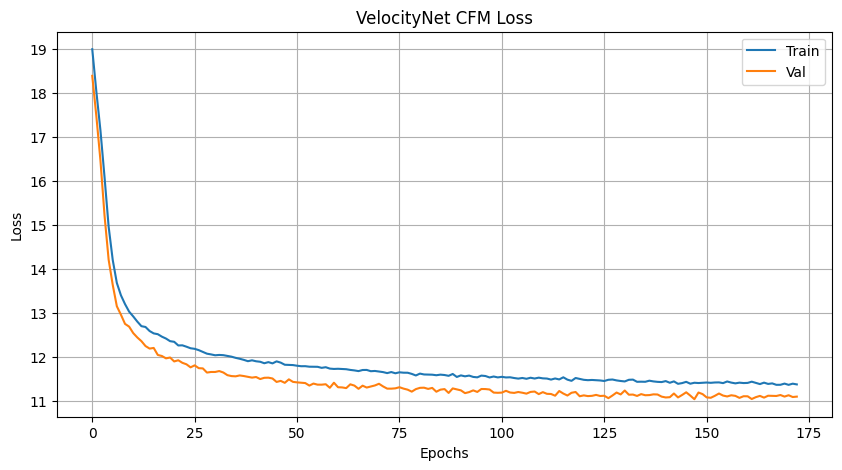

FM Final Training time: 00:11:48


In [17]:
model_fm = VelocityNet(
    num_layers=trial_fm.params["num_layers"],
    hidden_dim=trial_fm.params["hidden_dim"],
    dropout_rate=trial_fm.params["dropout_rate"],
).to(device)
optimizer_fm = torch.optim.AdamW(
    model_fm.parameters(),
    lr=trial_fm.params["lr"],
    weight_decay=trial_fm.params["weight_decay"],
)

# Retrain the model
with Timer("FM Final Training"):
    model_fm, _ = train_fm(model_fm, model_vae, optimizer_fm, train_loader_fm, val_loader_fm, plot_curves=True)

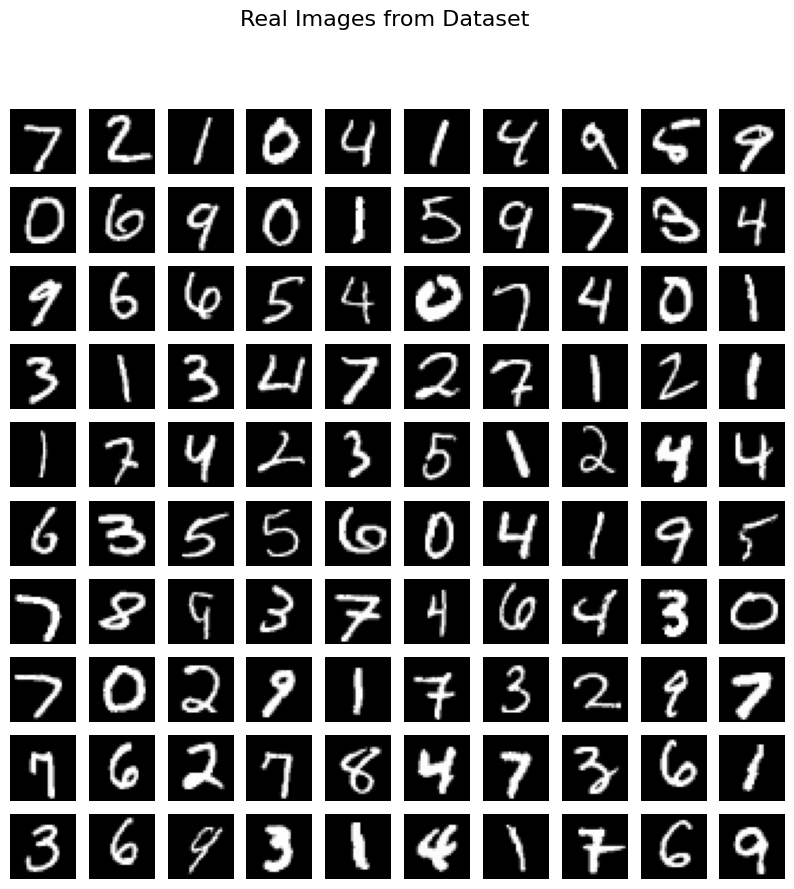

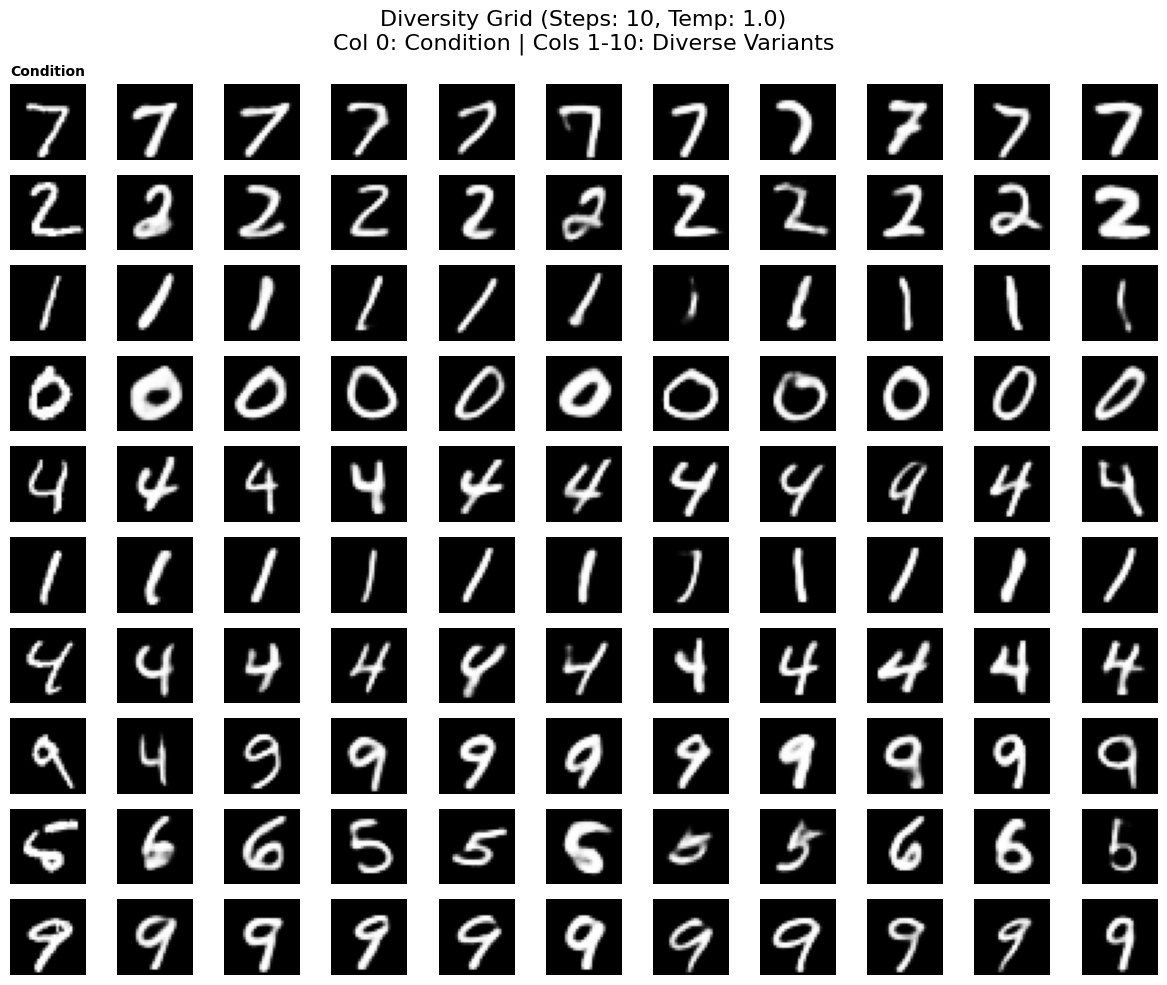

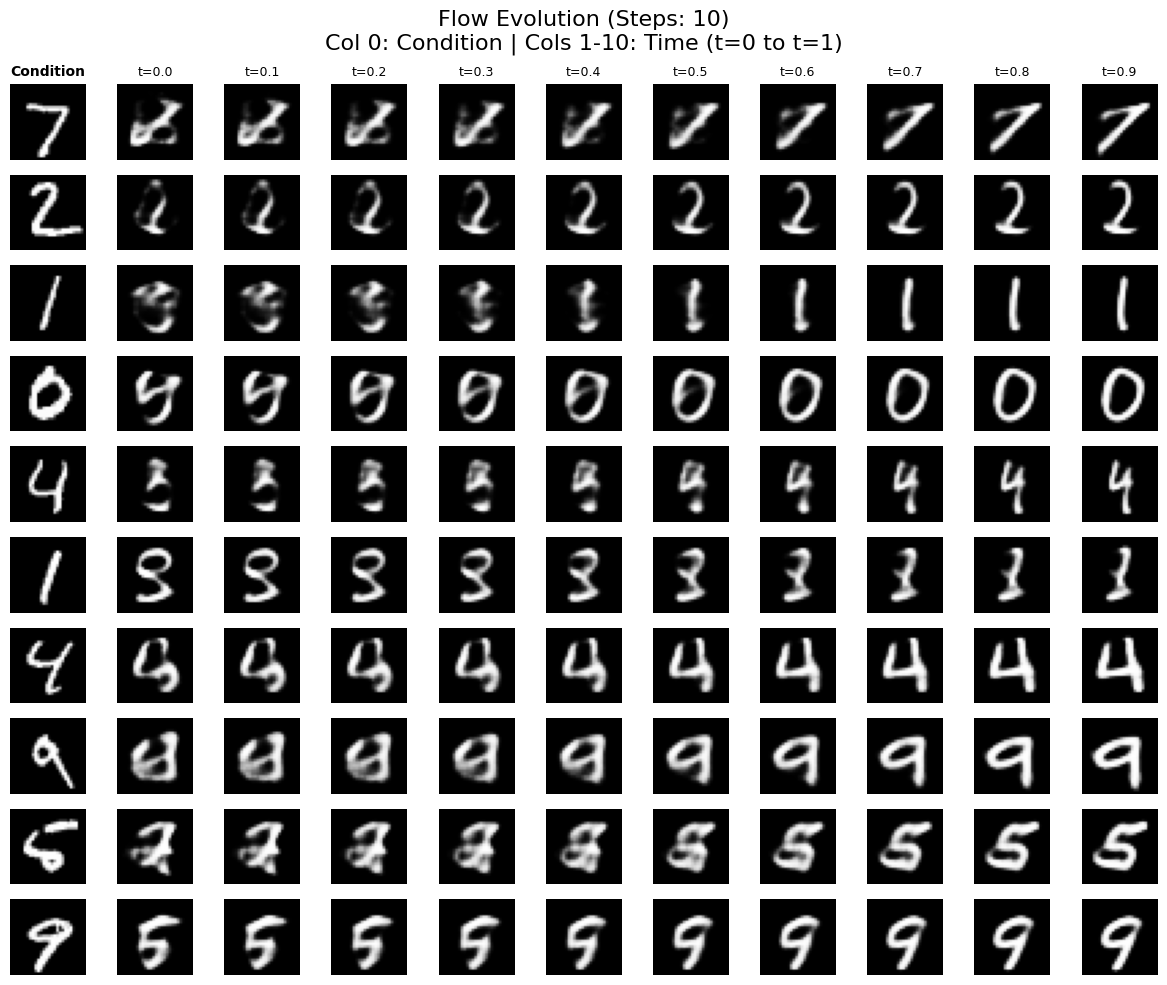

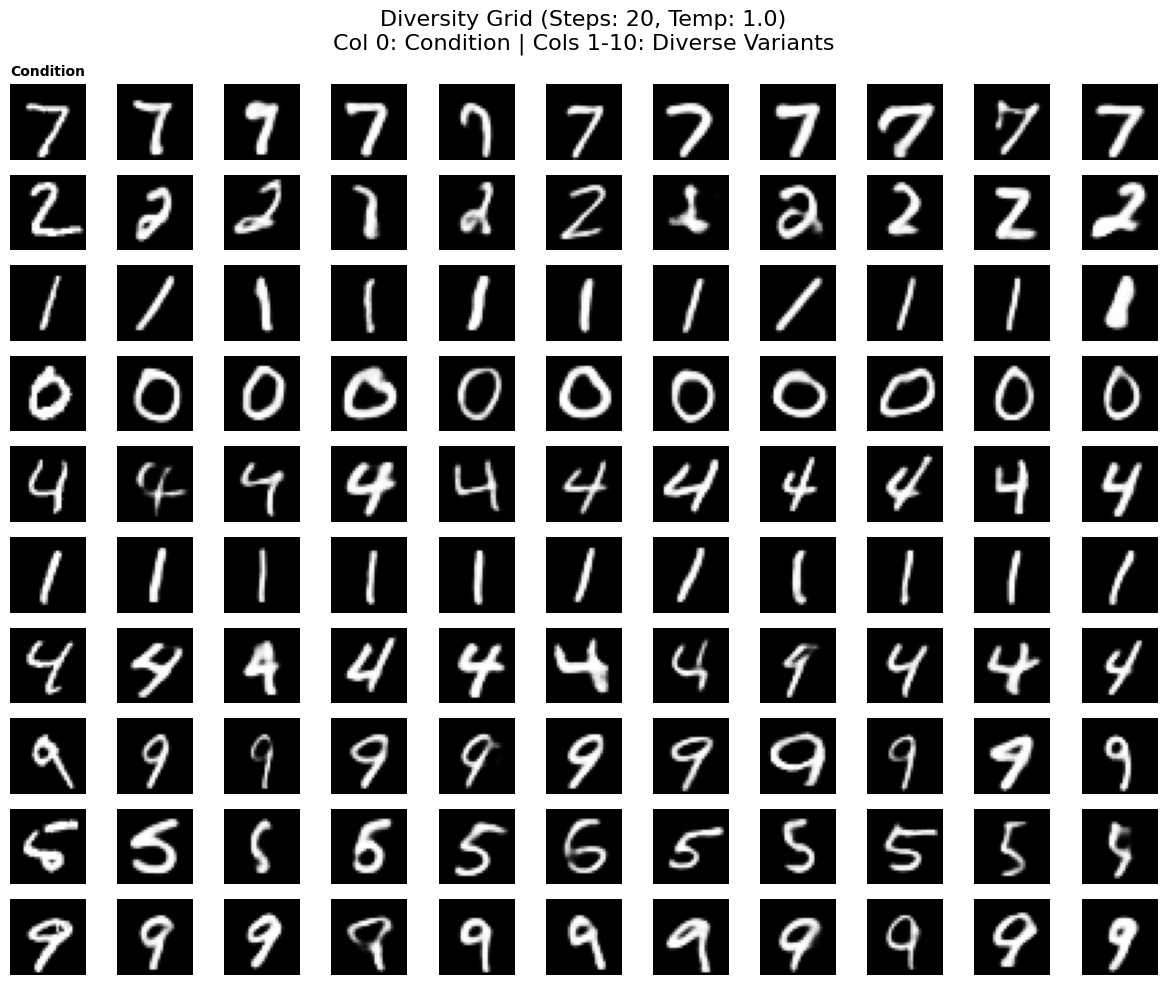

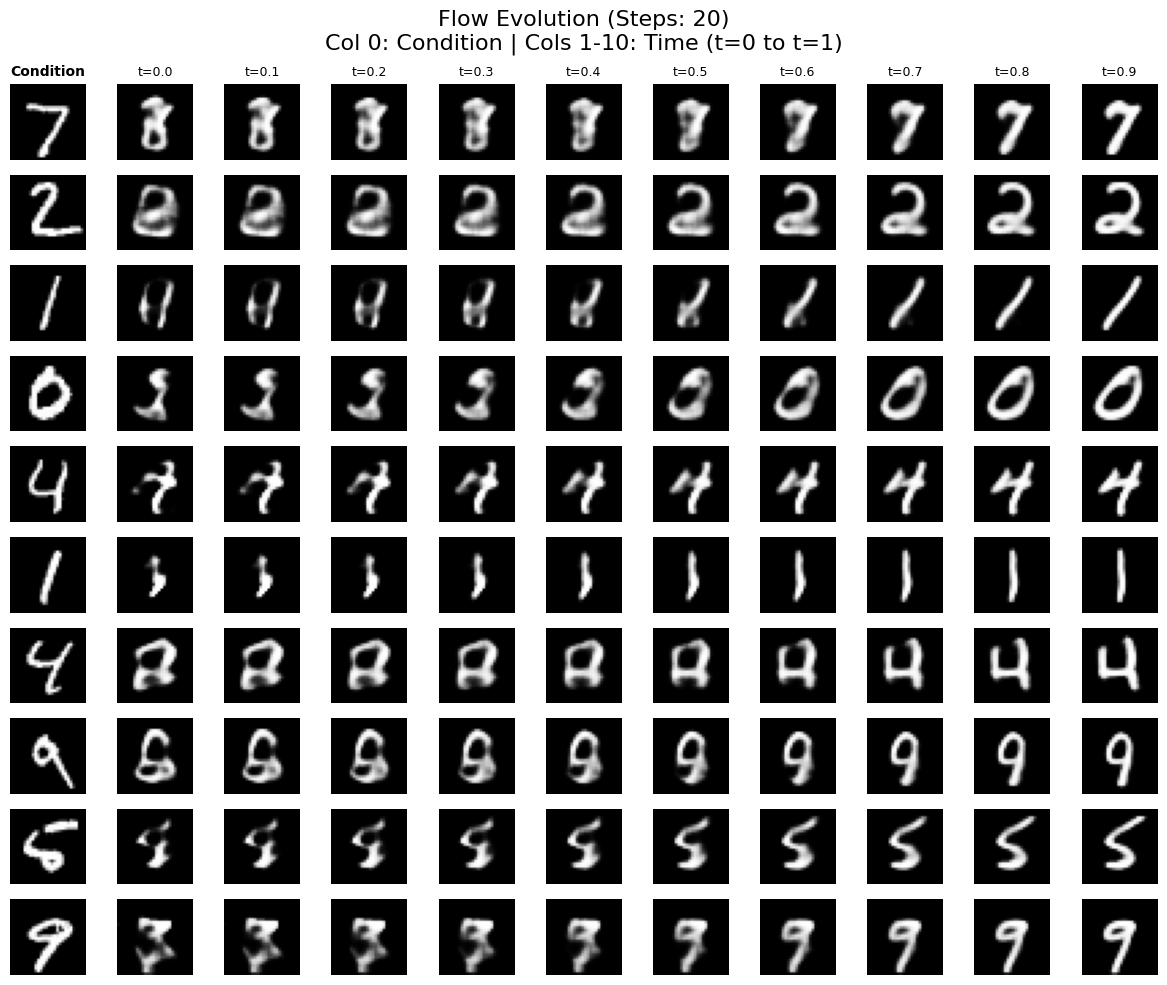

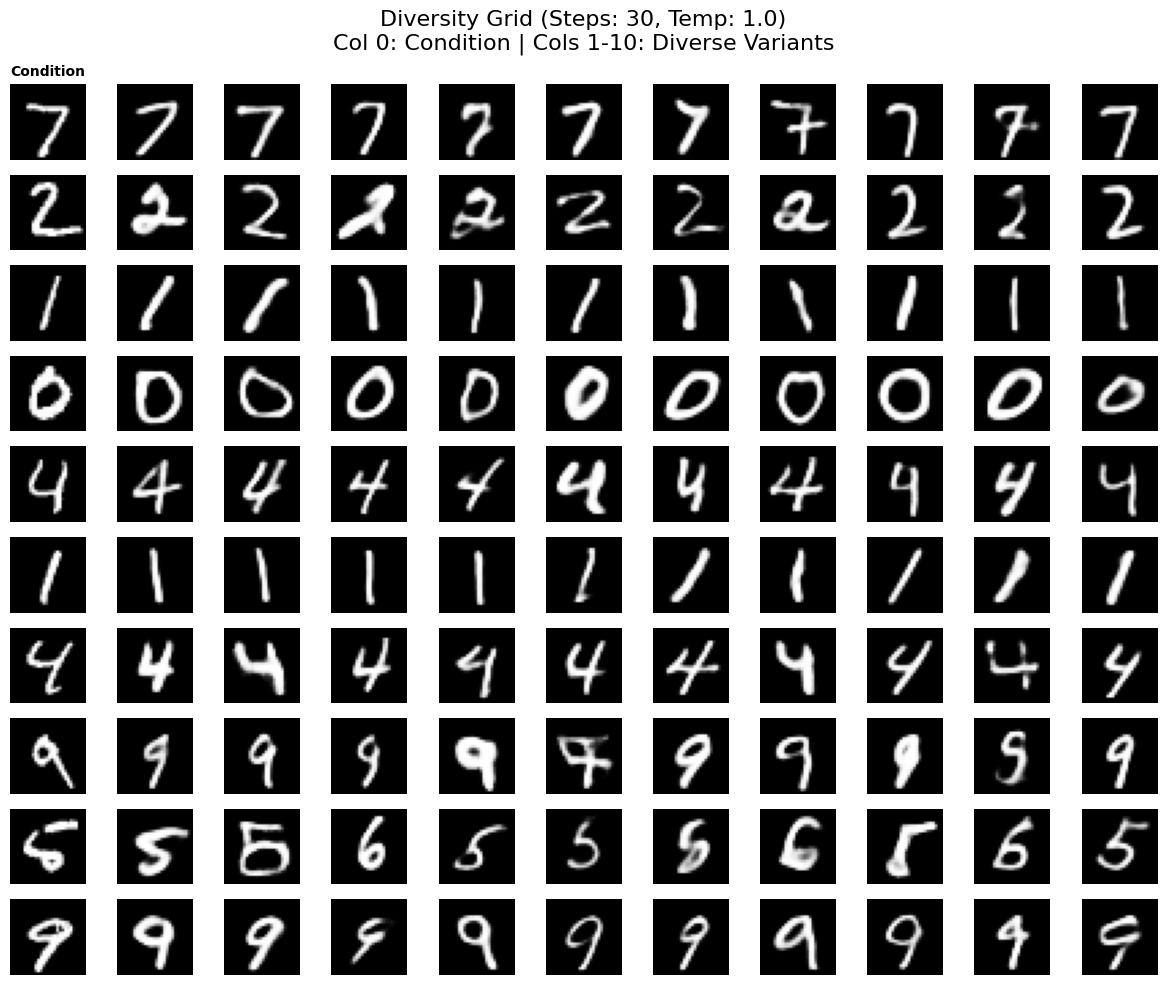

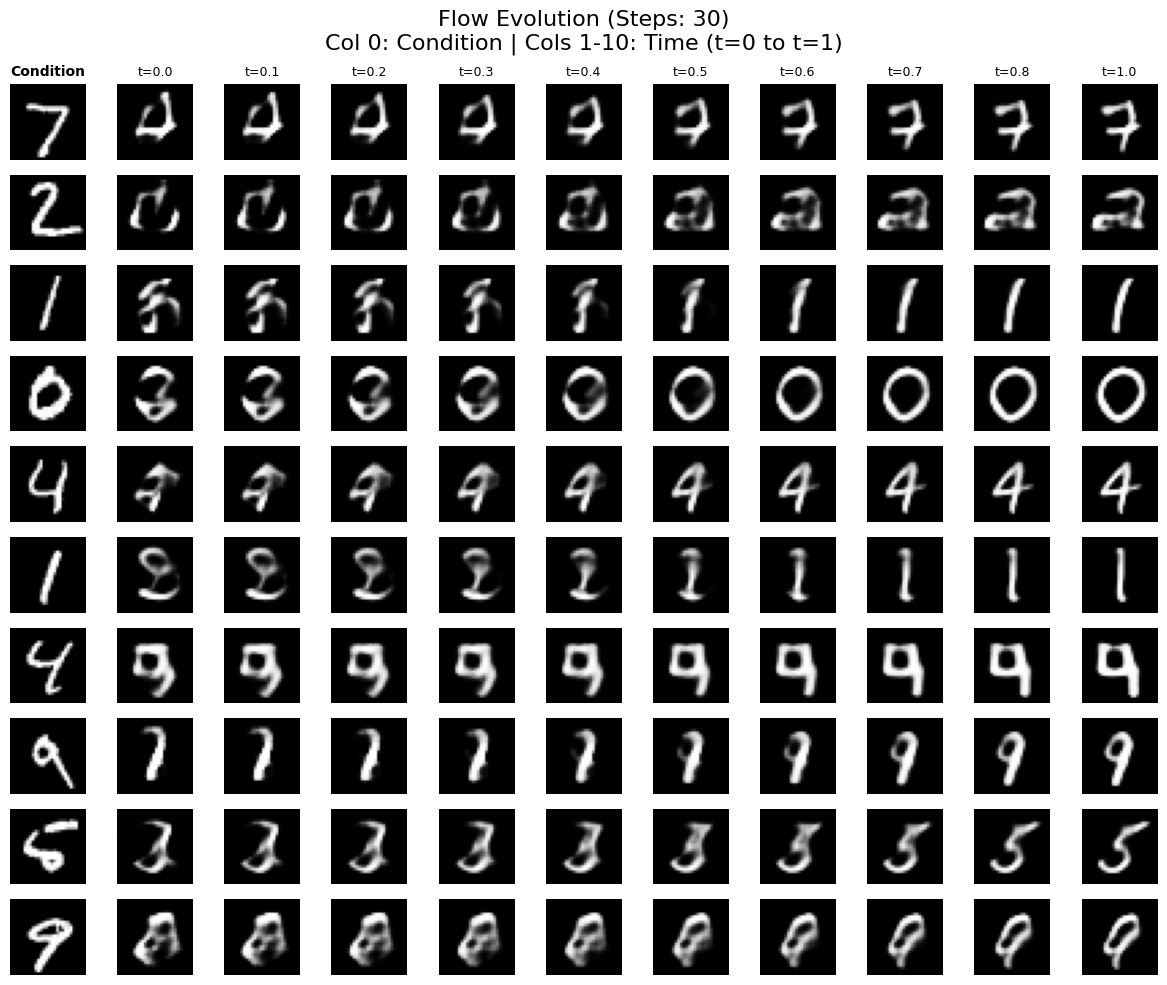

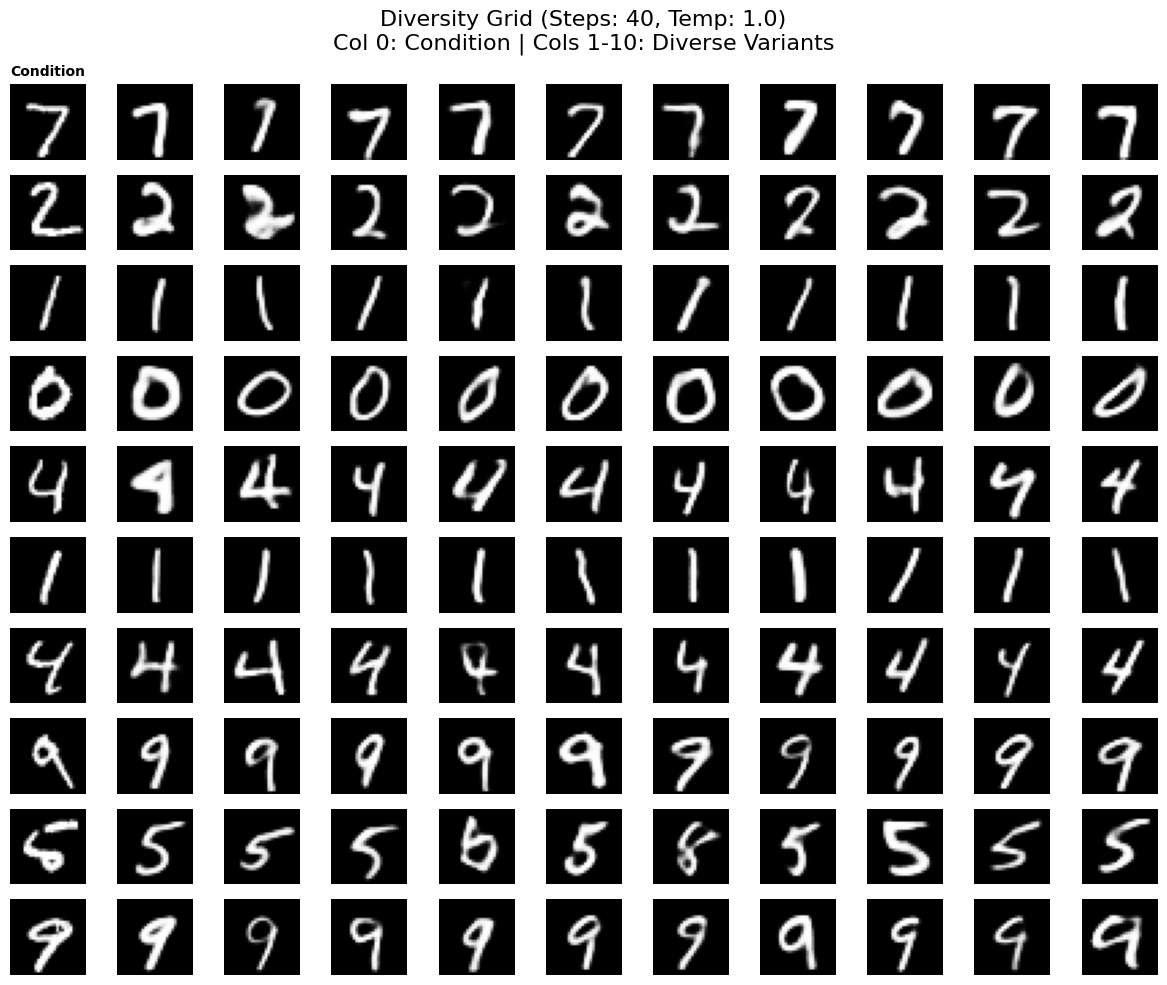

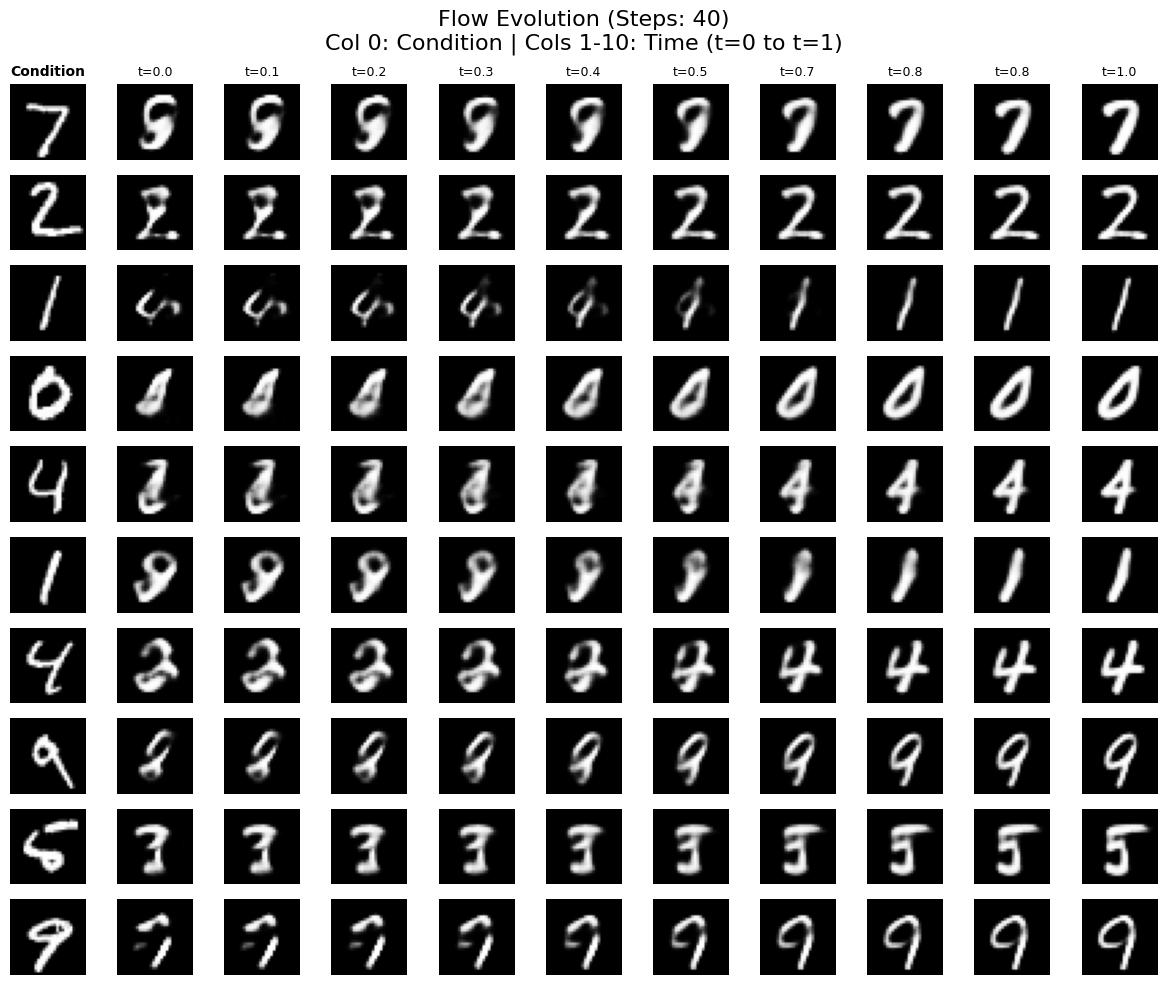

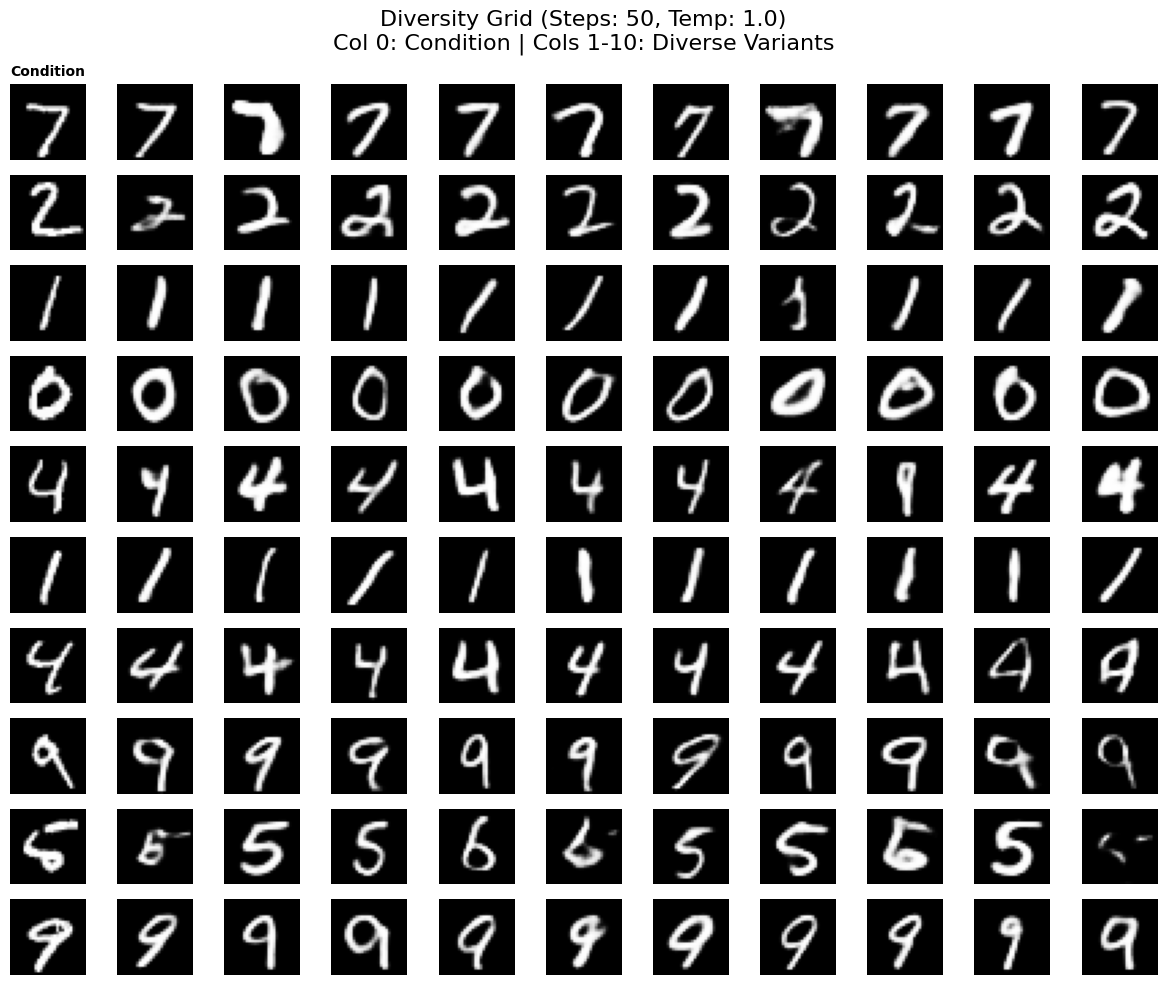

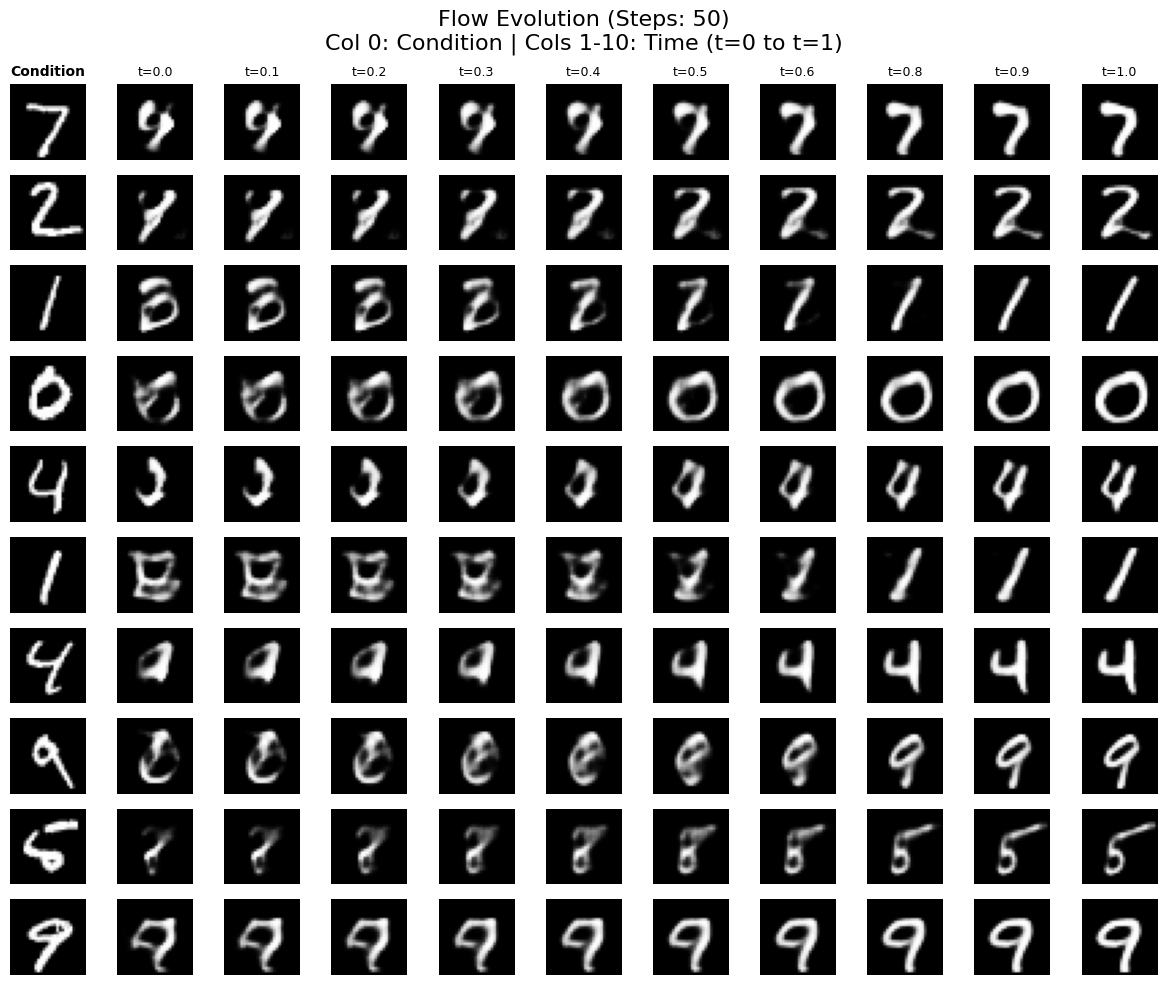

In [18]:
# Function for visualizing OT-CFM generations
@torch.no_grad()
def visualize_flow_performance(v_net, vae, data_loader, temperature=1.0, steps_list=STEPS_LIST):
    v_net.eval()
    vae.eval()

    # Get a batch of real data
    images, _ = next(iter(data_loader))
    images = images.to(device)

    # 100 REAL IMAGES FROM DATASET
    fig1, axes1 = plt.subplots(10, 10, figsize=(10, 10))
    fig1.suptitle("Real Images from Dataset", fontsize=16)
    for i, ax in enumerate(axes1.flat):
        ax.imshow(images[i].cpu().squeeze(), cmap="gray")
        ax.axis("off")
    plt.show()

    # Encode 10 conditions once to get the identity latents
    c_mu, _ = vae.encode(images[:10])

    for num_steps in steps_list:
        dt = 1.0 / num_steps

        # CONDITION + 10 DIVERSE VARIANTS
        fig1, axes1 = plt.subplots(10, 11, figsize=(12, 10))
        fig1.suptitle(
            f"Diversity Grid (Steps: {num_steps}, Temp: {temperature})\nCol 0: Condition | Cols 1-10: Diverse Variants",
            fontsize=16,
        )

        for i in range(10):
            # Show the Conditioning Image in the first column
            axes1[i, 0].imshow(images[i].cpu().squeeze(), cmap="gray")
            axes1[i, 0].axis("off")
            if i == 0:
                axes1[i, 0].set_title("Condition", fontsize=10, fontweight="bold")

            # Generate 10 variants in parallel
            c_repeated = c_mu[i : i + 1].expand(10, -1)
            z = torch.randn(10, LATENT_DIM).to(device) * temperature

            for step in range(num_steps):
                t = torch.ones(10, 1).to(device) * (step / num_steps)
                v = v_net(z, t, c_repeated)
                z = z + v * dt

            decoded = torch.sigmoid(vae.decode(z))

            # Plot variants in the remaining columns
            for j in range(10):
                axes1[i, j + 1].imshow(decoded[j].cpu().squeeze(), cmap="gray")
                axes1[i, j + 1].axis("off")

        plt.tight_layout()
        plt.show()

        # CONDITION + 10 EVOLUTION STEPS
        fig2, axes2 = plt.subplots(10, 11, figsize=(12, 10))
        fig2.suptitle(
            f"Flow Evolution (Steps: {num_steps})\nCol 0: Condition | Cols 1-10: Time (t=0 to t=1)", fontsize=16
        )

        # Take one variant for each of the 10 condition images
        z = torch.randn(10, 32).to(device) * temperature
        save_idx = np.linspace(0, num_steps - 1, 10, dtype=int)

        # Plot conditions in Col 0 first
        for row in range(10):
            axes2[row, 0].imshow(images[row].cpu().squeeze(), cmap="gray")
            axes2[row, 0].axis("off")
            if row == 0:
                axes2[row, 0].set_title("Condition", fontsize=10, fontweight="bold")

        step_tracker = 0
        for step in range(num_steps):
            t_val = step / num_steps
            t = torch.ones(10, 1).to(device) * t_val
            v = v_net(z, t, c_mu)
            z = z + v * dt

            if step in save_idx and step_tracker < 10:
                decoded_step = torch.sigmoid(vae.decode(z))
                for row in range(10):
                    # Plot at step_tracker + 1 to account for the condition column
                    axes2[row, step_tracker + 1].imshow(decoded_step[row].cpu().squeeze(), cmap="gray")
                    axes2[row, step_tracker + 1].axis("off")
                    if row == 0:
                        axes2[row, step_tracker + 1].set_title(f"t={t_val:.1f}", fontsize=9)
                step_tracker += 1

        plt.tight_layout()
        plt.show()


visualize_flow_performance(model_fm, model_vae, test_loader)